# Preparação para Modelagem

Este notebook consolida as decisões obtidas durante a análise exploratória e prepara a base enriquecida para o desenvolvimento dos modelos de classificação.

A estratégia experimental adota separação temporal entre os dados disponíveis:

- **2023:** conjunto de desenvolvimento, utilizado para preparação, seleção de variáveis, validação e escolha dos modelos;
- **2024:** conjunto de teste temporal final, mantido isolado durante as decisões de modelagem.

O objetivo é prever a condição de alfabetização dos alunos avaliados utilizando apenas informações consideradas disponíveis antes da avaliação, evitando vazamento de informação (*data leakage*).

As decisões adotadas neste notebook são fundamentadas nas análises realizadas no `01_eda_alunos_modelagem.ipynb`.

## 1. Objetivo e estratégia experimental

A modelagem será tratada como um problema de classificação binária, tendo `alfabetizado` como variável-alvo.

A população de modelagem é composta exclusivamente pelos alunos efetivamente avaliados, conforme definido na análise exploratória.

A estratégia adotada será:

- utilizar os dados de **2023** como conjunto de desenvolvimento;
- realizar seleção de variáveis, pré-processamento, treinamento, validação e escolha de modelos exclusivamente com os dados de 2023;
- utilizar `id_escola` para preservar o agrupamento dos alunos durante a validação;
- manter os dados de **2024 completamente isolados** até a avaliação temporal final;
- excluir identificadores, variáveis operacionais e características com evidência de vazamento de informação;
- utilizar informações externas do Censo Escolar respeitando a defasagem temporal:
  - avaliação de 2023 ← Censo Escolar 2022;
  - avaliação de 2024 ← Censo Escolar 2023.

Essa abordagem busca reproduzir uma situação mais próxima de uso real: estimar o risco de não alfabetização utilizando informações disponíveis antes da aplicação da avaliação.

## 2. Carregamento da base enriquecida

A base utilizada a partir deste ponto é o produto consolidado da etapa de enriquecimento realizada anteriormente.

Ela contém a população de alunos efetivamente avaliados e incorpora características contextuais do Censo Escolar agregadas por município e rede de ensino.

In [1]:
from pathlib import Path

import pandas as pd


DATA_PATH = Path("../data/processed/alunos_modelagem_enriquecido.parquet")

df = pd.read_parquet(DATA_PATH)

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]:,}")

Linhas: 3,354,661
Colunas: 97


## 3. Inventário das variáveis

Antes da definição do conjunto preditivo, as variáveis da base são inventariadas e classificadas de acordo com sua origem e função na modelagem.

Essa etapa permite separar explicitamente:

- variável-alvo;
- variáveis de controle e validação;
- identificadores;
- características provenientes da base Gold;
- metas de alfabetização;
- características contextuais provenientes do Censo Escolar.

As exclusões do conjunto preditivo serão realizadas posteriormente, com base nas evidências obtidas durante a análise exploratória.

In [2]:
inventario = pd.DataFrame({
    "posicao": range(1, len(df.columns) + 1),
    "variavel": df.columns,
    "tipo": [str(dtype) for dtype in df.dtypes],
})

inventario

,posicao,variavel,tipo
0,1,ano,Int64
1,2,id_municipio,string
2,3,id_municipio_nome,string
3,4,id_escola,string
4,5,id_aluno,string
...,...,...,...
92,93,cobertura_qt_doc_bas_pct,Float64
93,94,alunos_por_docente,Float64
94,95,alunos_por_sala,Float64
95,96,docentes_por_100_matriculas,Float64


### 3.1 Classificação funcional das variáveis

As variáveis são classificadas de acordo com sua função no experimento antes da definição do conjunto preditivo.

Uma variável não utilizada como *feature* pode continuar sendo necessária para controle temporal, validação, rastreabilidade ou avaliação do modelo.

A classificação considera as evidências obtidas durante a análise exploratória e separa as variáveis em:

- **alvo:** variável que será prevista;
- **controle:** utilizada na estratégia experimental, mas não como preditora;
- **identificador:** utilizada para rastreabilidade ou agrupamento;
- **exclusão por leakage/operacional:** informação indisponível ou inadequada no momento da previsão;
- **candidata Gold:** característica potencialmente utilizável proveniente da base original;
- **candidata Censo:** característica contextual construída a partir do Censo Escolar;
- **auditoria Censo:** característica mantida para controle de qualidade, mas não destinada ao conjunto preditivo.

In [3]:
def classificar_variavel(coluna):
    if coluna == "alfabetizado":
        return "alvo"

    if coluna in {"ano", "ano_censo"}:
        return "controle"

    if coluna in {
        "id_municipio",
        "id_municipio_nome",
        "id_escola",
        "id_aluno",
    }:
        return "identificador"

    if coluna in {
        "caderno",
        "presenca",
        "preenchimento_caderno",
        "proficiencia",
        "taxa_alfabetizacao",
        "media_portugues",
        "nivel_alfabetizacao",
        "percentual_participacao",
    }:
        return "exclusao_leakage_operacional"

    if coluna.startswith("cobertura_"):
        return "auditoria_censo"

    if coluna.startswith("meta_alfabetizacao_"):
        return "candidata_gold"

    if coluna in {"serie", "rede", "peso_aluno"}:
        return "candidata_gold"

    return "candidata_censo"


inventario["funcao"] = inventario["variavel"].apply(classificar_variavel)

inventario.groupby("funcao").size().sort_values(ascending=False)

funcao
candidata_censo                 43
auditoria_censo                 29
candidata_gold                  10
exclusao_leakage_operacional     8
identificador                    4
controle                         2
alvo                             1
dtype: int64

### 3.2 Revisão das variáveis candidatas da Gold

As variáveis classificadas inicialmente como `candidata_gold` exigem tratamento individual antes da definição do conjunto preditivo.

As decisões consideram as evidências já obtidas na análise exploratória:

- `serie` possui valor constante na população analisada e não acrescenta poder discriminativo;
- `rede` representa uma característica educacional disponível antes da avaliação e permanece como candidata;
- `peso_aluno` possui natureza amostral/estatística e não será utilizado diretamente como preditor;
- as metas de alfabetização apresentam forte redundância entre si;
- `meta_alfabetizacao_2030` é constante e não deve ser utilizada como feature;
- as demais metas devem ser reduzidas a uma representação não redundante, respeitando disponibilidade temporal.

In [4]:
candidatas_gold = inventario.loc[
    inventario["funcao"] == "candidata_gold",
    ["variavel", "tipo"]
].copy()

candidatas_gold

,variavel,tipo
6,serie,string
7,rede,str
12,peso_aluno,float64
17,meta_alfabetizacao_2024,float64
18,meta_alfabetizacao_2025,float64
19,meta_alfabetizacao_2026,float64
20,meta_alfabetizacao_2027,float64
21,meta_alfabetizacao_2028,float64
22,meta_alfabetizacao_2029,float64
23,meta_alfabetizacao_2030,float64


In [5]:
decisao_gold = {
    "serie": ("excluir", "variável constante na população de modelagem"),
    "rede": ("manter", "característica educacional disponível antes da avaliação"),
    "peso_aluno": ("excluir", "peso estatístico/amostral; não utilizado como preditor"),
    "meta_alfabetizacao_2024": ("excluir", "redundante com as demais metas"),
    "meta_alfabetizacao_2025": (
        "manter_provisoriamente",
        "representante das metas; disponibilidade temporal avaliada na EDA"
    ),
    "meta_alfabetizacao_2026": ("excluir", "redundante com meta_alfabetizacao_2025"),
    "meta_alfabetizacao_2027": ("excluir", "redundante com meta_alfabetizacao_2025"),
    "meta_alfabetizacao_2028": ("excluir", "redundante com meta_alfabetizacao_2025"),
    "meta_alfabetizacao_2029": ("excluir", "redundante com meta_alfabetizacao_2025"),
    "meta_alfabetizacao_2030": ("excluir", "variável constante"),
}

decisoes_gold = pd.DataFrame(
    [
        {
            "variavel": variavel,
            "decisao": decisao,
            "justificativa": justificativa,
        }
        for variavel, (decisao, justificativa) in decisao_gold.items()
    ]
)

decisoes_gold

,variavel,decisao,justificativa
0,serie,excluir,variável constante na população de modelagem
1,rede,manter,característica educacional disponível antes da...
2,peso_aluno,excluir,peso estatístico/amostral; não utilizado como ...
3,meta_alfabetizacao_2024,excluir,redundante com as demais metas
4,meta_alfabetizacao_2025,manter_provisoriamente,representante das metas; disponibilidade tempo...
5,meta_alfabetizacao_2026,excluir,redundante com meta_alfabetizacao_2025
6,meta_alfabetizacao_2027,excluir,redundante com meta_alfabetizacao_2025
7,meta_alfabetizacao_2028,excluir,redundante com meta_alfabetizacao_2025
8,meta_alfabetizacao_2029,excluir,redundante com meta_alfabetizacao_2025
9,meta_alfabetizacao_2030,excluir,variável constante


### 3.3 Revisão das características do Censo Escolar

As características provenientes do Censo Escolar representam informações contextuais agregadas por município e rede de ensino.

A análise exploratória identificou dois grupos distintos:

- características substantivas, relacionadas à infraestrutura, localização, matrículas, docentes e recursos educacionais;
- métricas `cobertura_*`, criadas durante o processamento para auditoria da completude dos dados.

As métricas de cobertura são preservadas na base para rastreabilidade e controle de qualidade, mas não serão utilizadas como preditores. A EDA mostrou que essas variáveis apresentam baixa variabilidade e forte redundância entre si.

A seleção das características substantivas será realizada exclusivamente sobre o conjunto de desenvolvimento de 2023. O conjunto temporal de 2024 não participa de nenhuma decisão de seleção de variáveis.

In [6]:
candidatas_censo = inventario.loc[
    inventario["funcao"] == "candidata_censo",
    "variavel"
].tolist()

print(f"Features substantivas candidatas: {len(candidatas_censo)}")

pd.DataFrame({
    "variavel": candidatas_censo
})

Features substantivas candidatas: 43


,variavel
0,TP_DEPENDENCIA
1,qtd_escolas
2,pct_info_detalhada_completa
3,pct_tp_localizacao_1
4,pct_tp_localizacao_2
5,pct_localizacao_diferenciada
6,pct_in_agua_potavel
7,pct_in_agua_rede_publica
8,pct_in_energia_rede_publica
9,pct_in_esgoto_rede_publica


In [7]:
df_dev = df.loc[df["ano"] == 2023]

variabilidade_censo = pd.DataFrame({
    "variavel": candidatas_censo,
    "n_unicos": [
        df_dev[coluna].nunique(dropna=True)
        for coluna in candidatas_censo
    ],
    "pct_nulos": [
        df_dev[coluna].isna().mean() * 100
        for coluna in candidatas_censo
    ],
})

variabilidade_censo = variabilidade_censo.sort_values(
    ["n_unicos", "variavel"]
).reset_index(drop=True)

variabilidade_censo

,variavel,n_unicos,pct_nulos
0,TP_DEPENDENCIA,2,0.000000
1,qtd_escolas,172,0.000000
2,pct_in_energia_rede_publica,211,0.000000
3,pct_in_acessibilidade_sinal_visual,326,0.000000
4,pct_in_laboratorio_ciencias,330,0.000000
5,total_qt_tablet_aluno,331,0.000000
6,pct_in_agua_potavel,336,0.000000
7,total_qt_comp_portatil_aluno,345,0.000000
8,pct_localizacao_diferenciada,401,0.000000
9,total_qt_desktop_aluno,432,0.000000


#### 3.3.1 Redundância entre características substantivas

Nenhuma das 43 características substantivas do Censo Escolar apresentou ausência de variabilidade no conjunto de desenvolvimento de 2023.

A análise de redundância é realizada exclusivamente sobre 2023 e considera as características numéricas. Pares com correlação absoluta igual ou superior a 0,95 são identificados para revisão.

A correlação elevada não implica exclusão automática. A decisão também considera a semântica das variáveis e se ambas representam essencialmente a mesma informação.

In [8]:
censo_numericas = [
    coluna
    for coluna in candidatas_censo
    if pd.api.types.is_numeric_dtype(df_dev[coluna])
]

corr_censo = (
    df_dev[censo_numericas]
    .corr()
    .abs()
)

pares_redundantes = []

for i, coluna_a in enumerate(censo_numericas):
    for coluna_b in censo_numericas[i + 1:]:
        correlacao = corr_censo.loc[coluna_a, coluna_b]

        if correlacao >= 0.95:
            pares_redundantes.append({
                "variavel_a": coluna_a,
                "variavel_b": coluna_b,
                "correlacao_abs": correlacao,
            })

pares_redundantes = (
    pd.DataFrame(pares_redundantes)
    .sort_values("correlacao_abs", ascending=False)
    .reset_index(drop=True)
)

print(f"Pares com |correlação| >= 0,95: {len(pares_redundantes)}")

pares_redundantes

Pares com |correlação| >= 0,95: 8


,variavel_a,variavel_b,correlacao_abs
0,pct_tp_localizacao_1,pct_tp_localizacao_2,1.000000
1,total_qt_salas_utilizadas,total_qt_mat_bas,0.994815
2,total_qt_mat_bas,total_qt_doc_bas,0.990558
3,total_qt_salas_utilizadas,total_qt_doc_bas,0.990335
4,pct_info_detalhada_completa,pct_in_internet,0.989601
5,qtd_escolas,total_qt_salas_utilizadas,0.989494
6,qtd_escolas,total_qt_mat_bas,0.983129
7,qtd_escolas,total_qt_doc_bas,0.971170


In [9]:
variaveis_redundancia = [
    "qtd_escolas",
    "total_qt_salas_utilizadas",
    "total_qt_mat_bas",
    "total_qt_doc_bas",
    "alunos_por_docente",
    "alunos_por_sala",
    "docentes_por_100_matriculas",
    "pct_info_detalhada_completa",
    "pct_in_internet",
]

df_dev[variaveis_redundancia].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]

,mean,std,min,25%,50%,75%,max
qtd_escolas,123.805363,271.703455,1.0,17.0,40.0,106.0,1564.0
total_qt_salas_utilizadas,1231.162076,2941.568424,2.0,120.0,314.0,918.0,16710.0
total_qt_mat_bas,46933.21825,111967.928668,94.0,3647.0,10484.0,34615.0,625433.0
total_qt_doc_bas,2325.3909,5001.029697,8.0,223.0,594.0,1900.0,27229.0
alunos_por_docente,17.940131,4.399024,4.424242,14.682243,17.519231,21.188197,43.803625
alunos_por_sala,34.589176,8.896226,4.717391,28.176471,34.910891,40.52802,175.0
docentes_por_100_matriculas,5.940693,1.580848,2.282916,4.719609,5.708013,6.810948,22.60274
pct_info_detalhada_completa,89.874506,17.394136,0.0,88.0,97.69821,100.0,100.0
pct_in_internet,90.665614,17.457792,0.0,89.380531,99.528302,100.0,100.0


In [10]:
exclusoes_censo = {
    "pct_tp_localizacao_2": (
        "complemento exato de pct_tp_localizacao_1"
    ),
    "total_qt_salas_utilizadas": (
        "redundante com o indicador de porte da rede"
    ),
    "total_qt_mat_bas": (
        "redundante com o indicador de porte da rede"
    ),
    "total_qt_doc_bas": (
        "redundante com o indicador de porte da rede"
    ),
    "docentes_por_100_matriculas": (
        "transformação inversamente relacionada a alunos_por_docente"
    ),
    "pct_info_detalhada_completa": (
        "indicador de completude da fonte e altamente redundante com pct_in_internet"
    ),
    "TP_DEPENDENCIA": (
    "campo técnico do Censo redundante com a variável rede"
    ),
    "total_qt_tablet_aluno": (
    "redundante com media_qt_tablet_aluno e influenciado pelo porte da rede"
    ),
}

features_censo_selecionadas = [
    coluna
    for coluna in candidatas_censo
    if coluna not in exclusoes_censo
]

print(f"Candidatas originais: {len(candidatas_censo)}")
print(f"Excluídas: {len(exclusoes_censo)}")
print(f"Selecionadas: {len(features_censo_selecionadas)}")

Candidatas originais: 43
Excluídas: 8
Selecionadas: 35


#### 3.3.2 Validação da redundância após seleção

Após as exclusões definidas por redundância estatística e semântica, a correlação entre as características substantivas selecionadas é recalculada sobre o conjunto de desenvolvimento de 2023.

O objetivo é verificar se permanecem pares com correlação absoluta igual ou superior a 0,95.

In [11]:
censo_numericas_selecionadas = [
    coluna
    for coluna in features_censo_selecionadas
    if pd.api.types.is_numeric_dtype(df_dev[coluna])
]

corr_censo_selecionado = (
    df_dev[censo_numericas_selecionadas]
    .corr(method="spearman")
    .abs()
)

pares_redundantes_pos = []

for i, coluna_a in enumerate(censo_numericas_selecionadas):
    for coluna_b in censo_numericas_selecionadas[i + 1:]:
        correlacao = corr_censo_selecionado.loc[coluna_a, coluna_b]

        if correlacao >= 0.95:
            pares_redundantes_pos.append({
                "variavel_a": coluna_a,
                "variavel_b": coluna_b,
                "correlacao_abs": correlacao,
            })

pares_redundantes_pos = pd.DataFrame(pares_redundantes_pos)

print(
    "Pares restantes com |correlação| >= 0,95:",
    len(pares_redundantes_pos)
)

pares_redundantes_pos

Pares restantes com |correlação| >= 0,95: 0


""


### 3.4 Conjunto de características para modelagem

Após a revisão das variáveis da Gold e das características contextuais do Censo Escolar, é consolidado o conjunto de preditores que seguirá para a etapa de modelagem.

As decisões adotadas foram:

- exclusão de identificadores do conjunto preditivo;
- exclusão de variáveis operacionais e com evidência de *data leakage*;
- exclusão das métricas `cobertura_*`, mantidas apenas para auditoria;
- exclusão de características constantes ou estruturalmente redundantes;
- preservação de `rede` como característica categórica;
- utilização provisória de `meta_alfabetizacao_2025` como representante das metas de alfabetização;
- seleção de 37 características substantivas do Censo Escolar.

As decisões de seleção foram realizadas exclusivamente sobre o conjunto de desenvolvimento de 2023. O conjunto temporal de 2024 permanece isolado.

In [12]:
features_gold_selecionadas = [
    "rede",
    "meta_alfabetizacao_2025",
]

features_modelagem = (
    features_gold_selecionadas
    + features_censo_selecionadas
)

print(f"Features Gold: {len(features_gold_selecionadas)}")
print(f"Features Censo: {len(features_censo_selecionadas)}")
print(f"Total de features: {len(features_modelagem)}")

pd.DataFrame({
    "variavel": features_modelagem,
    "origem": (
        ["Gold"] * len(features_gold_selecionadas)
        + ["Censo Escolar"] * len(features_censo_selecionadas)
    )
})

Features Gold: 2
Features Censo: 35
Total de features: 37


,variavel,origem
0,rede,Gold
1,meta_alfabetizacao_2025,Gold
2,qtd_escolas,Censo Escolar
3,pct_tp_localizacao_1,Censo Escolar
4,pct_localizacao_diferenciada,Censo Escolar
5,pct_in_agua_potavel,Censo Escolar
6,pct_in_agua_rede_publica,Censo Escolar
7,pct_in_energia_rede_publica,Censo Escolar
8,pct_in_esgoto_rede_publica,Censo Escolar
9,pct_in_lixo_servico_coleta,Censo Escolar


In [13]:
assert len(features_modelagem) == len(set(features_modelagem))
assert set(features_modelagem).issubset(df.columns)

print("Conjunto de features validado.")

Conjunto de features validado.


## 4. Separação temporal e definição do target

A estratégia experimental utiliza uma separação temporal explícita:

- **2023:** conjunto de desenvolvimento, utilizado para treinamento, validação, seleção de modelos e ajuste de hiperparâmetros;
- **2024:** conjunto de teste temporal final, mantido isolado até a avaliação do modelo selecionado.

O problema é formulado como classificação de risco. Por isso, a variável-alvo é codificada como:

- `1` — aluno **não alfabetizado**;
- `0` — aluno **alfabetizado**.

Essa convenção torna métricas como *recall*, *precision* e F1 diretamente interpretáveis em relação à identificação dos alunos em risco de não alfabetização.

O identificador `id_escola` não é utilizado como preditor. Ele é preservado separadamente para garantir que alunos da mesma escola permaneçam no mesmo grupo durante a validação do conjunto de desenvolvimento.

In [14]:
TARGET = "alfabetizado"
GROUP = "id_escola"

mask_dev = df["ano"] == 2023
mask_test = df["ano"] == 2024

X_dev = df.loc[mask_dev, features_modelagem].copy()
X_test = df.loc[mask_test, features_modelagem].copy()

y_dev = (
    df.loc[mask_dev, TARGET]
    .map({"Sim": 0, "Não": 1})
    .astype("int8")
)

y_test = (
    df.loc[mask_test, TARGET]
    .map({"Sim": 0, "Não": 1})
    .astype("int8")
)

groups_dev = df.loc[mask_dev, GROUP].copy()

print(f"Desenvolvimento 2023: {len(X_dev):,}")
print(f"Teste temporal 2024: {len(X_test):,}")
print(f"Features: {X_dev.shape[1]}")
print(f"Escolas no desenvolvimento: {groups_dev.nunique():,}")

Desenvolvimento 2023: 1,502,809
Teste temporal 2024: 1,851,852
Features: 37
Escolas no desenvolvimento: 36,525


In [15]:
distribuicao_target = pd.DataFrame({
    "quantidade": y_dev.value_counts().sort_index(),
    "percentual": y_dev.value_counts(normalize=True).sort_index() * 100,
})

distribuicao_target.index = [
    "0 - Alfabetizado",
    "1 - Não alfabetizado",
]

distribuicao_target

,quantidade,percentual
0 - Alfabetizado,877427,58.385796
1 - Não alfabetizado,625382,41.614204


## 5. Estratégia de validação cruzada

A avaliação interna do conjunto de desenvolvimento de 2023 utiliza validação cruzada estratificada e agrupada por escola.

O `StratifiedGroupKFold` foi escolhido para atender simultaneamente a dois requisitos:

- impedir que alunos da mesma escola apareçam nos conjuntos de treino e validação de um mesmo fold;
- buscar a preservação da distribuição da variável-alvo entre os folds.

Essa estratégia reduz o risco de resultados excessivamente otimistas decorrentes do compartilhamento do contexto escolar entre treino e validação.

O conjunto temporal de 2024 permanece completamente fora desse processo.

In [16]:
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 5
RANDOM_STATE = 42

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resumo_folds = []

for fold, (idx_treino, idx_validacao) in enumerate(
    cv.split(X_dev, y_dev, groups=groups_dev),
    start=1,
):
    y_treino_fold = y_dev.iloc[idx_treino]
    y_validacao_fold = y_dev.iloc[idx_validacao]

    escolas_treino = set(groups_dev.iloc[idx_treino])
    escolas_validacao = set(groups_dev.iloc[idx_validacao])

    resumo_folds.append({
        "fold": fold,
        "n_treino": len(idx_treino),
        "n_validacao": len(idx_validacao),
        "risco_treino_pct": y_treino_fold.mean() * 100,
        "risco_validacao_pct": y_validacao_fold.mean() * 100,
        "escolas_treino": len(escolas_treino),
        "escolas_validacao": len(escolas_validacao),
        "escolas_em_comum": len(
            escolas_treino.intersection(escolas_validacao)
        ),
    })

resumo_folds = pd.DataFrame(resumo_folds)

resumo_folds

,fold,n_treino,n_validacao,risco_treino_pct,risco_validacao_pct,escolas_treino,escolas_validacao,escolas_em_comum
0,1,1202258,300551,41.614362,41.613570,29231,7294,0
1,2,1202246,300563,41.613863,41.615568,29225,7300,0
2,3,1202238,300571,41.614472,41.613130,29230,7295,0
3,4,1202224,300585,41.614125,41.614518,29194,7331,0
4,5,1202270,300539,41.614196,41.614233,29220,7305,0


In [17]:
assert (resumo_folds["escolas_em_comum"] == 0).all()

print(
    "Variação da classe de risco na validação:",
    f"{resumo_folds['risco_validacao_pct'].min():.2f}% - "
    f"{resumo_folds['risco_validacao_pct'].max():.2f}%"
)

print("Separação por escola validada.")

Variação da classe de risco na validação: 41.61% - 41.62%
Separação por escola validada.


## 6. Preparação do pipeline de pré-processamento

O pré-processamento será incorporado ao pipeline de modelagem para evitar vazamento de informação entre os folds da validação cruzada.

As transformações serão ajustadas exclusivamente sobre os dados de treinamento de cada fold e posteriormente aplicadas à respectiva validação.

Nesta etapa, as características são separadas entre numéricas e categóricas antes da definição das transformações.

In [18]:
features_categoricas = [
    coluna
    for coluna in features_modelagem
    if not pd.api.types.is_numeric_dtype(X_dev[coluna])
]

features_numericas = [
    coluna
    for coluna in features_modelagem
    if pd.api.types.is_numeric_dtype(X_dev[coluna])
]

print(f"Features categóricas: {len(features_categoricas)}")
print(features_categoricas)

print(f"\nFeatures numéricas: {len(features_numericas)}")
print(features_numericas)

Features categóricas: 1
['rede']

Features numéricas: 36
['meta_alfabetizacao_2025', 'qtd_escolas', 'pct_tp_localizacao_1', 'pct_localizacao_diferenciada', 'pct_in_agua_potavel', 'pct_in_agua_rede_publica', 'pct_in_energia_rede_publica', 'pct_in_esgoto_rede_publica', 'pct_in_lixo_servico_coleta', 'pct_in_banheiro_pne', 'pct_in_biblioteca', 'pct_in_biblioteca_sala_leitura', 'pct_in_laboratorio_ciencias', 'pct_in_laboratorio_informatica', 'pct_in_patio_coberto', 'pct_in_patio_descoberto', 'pct_in_parque_infantil', 'pct_in_quadra_esportes', 'pct_in_acessibilidade_corrimao', 'pct_in_acessibilidade_rampas', 'pct_in_acessibilidade_sinal_visual', 'pct_in_computador', 'pct_in_internet', 'pct_in_internet_aprendizagem', 'pct_in_banda_larga', 'media_qt_salas_utilizadas', 'media_qt_desktop_aluno', 'total_qt_desktop_aluno', 'media_qt_comp_portatil_aluno', 'total_qt_comp_portatil_aluno', 'media_qt_tablet_aluno', 'media_qt_mat_bas', 'media_qt_doc_bas', 'alunos_por_docente', 'alunos_por_sala', 'dispos

### 6.1 Pré-processamento para modelos lineares

Para os modelos lineares, o pré-processamento é composto por:

- imputação das variáveis numéricas pela mediana;
- padronização das variáveis numéricas com `StandardScaler`;
- imputação da variável categórica pela categoria mais frequente;
- codificação da variável `rede` por `OneHotEncoder`.

Todas as transformações permanecem dentro do pipeline do scikit-learn. Dessa forma, seus parâmetros são aprendidos somente sobre os dados de treinamento de cada fold, evitando vazamento de informação durante a validação cruzada.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pipeline_numerico_linear = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
            ),
        ),
    ]
)

preprocessor_linear = ColumnTransformer(
    transformers=[
        (
            "numeric",
            pipeline_numerico_linear,
            features_numericas,
        ),
        (
            "categorical",
            pipeline_categorico,
            features_categoricas,
        ),
    ],
    remainder="drop",
)

print(preprocessor_linear)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['meta_alfabetizacao_2025', 'qtd_escolas',
                                  'pct_tp_localizacao_1',
                                  'pct_localizacao_diferenciada',
                                  'pct_in_agua_potavel',
                                  'pct_in_agua_rede_publica',
                                  'pct_in_energia_rede_publica',
                                  'pct_in_esgoto_rede_publica',
                                  'pct_in_lixo_...
                                  'pct_in_internet_aprendizagem',
                                  'pct_in_banda_larga',
                                  'media_qt_salas_utilizadas',
                                  'media_qt_d

## 7. Modelagem

A modelagem é iniciada com um baseline simples, utilizado como referência para avaliar se os modelos supervisionados efetivamente acrescentam capacidade preditiva.

Todo o processo de avaliação utiliza exclusivamente o conjunto de desenvolvimento de 2023 e a estratégia de validação cruzada definida anteriormente. O conjunto temporal de 2024 permanece reservado para a avaliação final.

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

baseline = DummyClassifier(
    strategy="prior",
)

metricas = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

resultado_baseline = cross_validate(
    baseline,
    X_dev,
    y_dev,
    groups=groups_dev,
    cv=cv,
    scoring=metricas,
    n_jobs=-1,
)

resumo_baseline = pd.DataFrame({
    metrica: [
        resultado_baseline[f"test_{metrica}"].mean(),
        resultado_baseline[f"test_{metrica}"].std(),
    ]
    for metrica in metricas
}, index=["media", "desvio_padrao"])

resumo_baseline.T

/home/erick/Projetos/tech_challenge_3_alfabetizacao/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/erick/Projetos/tech_challenge_3_alfabetizacao/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/erick/Projetos/tech_challenge_3_alfabetizacao/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavio

,media,desvio_padrao
roc_auc,0.500000,0.000000
average_precision,0.416142,0.000008
balanced_accuracy,0.500000,0.000000
precision,0.000000,0.000000
recall,0.000000,0.000000
f1,0.000000,0.000000


#### Resultado do baseline

O `DummyClassifier` apresentou ROC-AUC e balanced accuracy iguais a 0,50, comportamento esperado para um classificador sem capacidade discriminativa.

Como a classe majoritária do conjunto de desenvolvimento corresponde aos alunos alfabetizados, o baseline não identificou alunos da classe positiva de risco (`Não alfabetizado`), resultando em precision, recall e F1 iguais a zero.

Esses resultados estabelecem a referência mínima para comparação com os modelos supervisionados.

### 7.2 Regressão Logística

A Regressão Logística é utilizada como primeiro modelo supervisionado por oferecer uma referência linear interpretável para comparação com modelos mais complexos.

O pré-processamento é incorporado ao pipeline para garantir que imputação, padronização e codificação sejam ajustadas exclusivamente sobre o conjunto de treinamento de cada fold.

In [21]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline(
    steps=[
        ("preprocessor", preprocessor_linear),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

resultado_logistico = cross_validate(
    modelo_logistico,
    X_dev,
    y_dev,
    groups=groups_dev,
    cv=cv,
    scoring=metricas,
    n_jobs=-1,
)

resumo_logistico = pd.DataFrame({
    metrica: [
        resultado_logistico[f"test_{metrica}"].mean(),
        resultado_logistico[f"test_{metrica}"].std(),
    ]
    for metrica in metricas
}, index=["media", "desvio_padrao"])

resumo_logistico.T

,media,desvio_padrao
roc_auc,0.680330,0.001840
average_precision,0.588163,0.001541
balanced_accuracy,0.605193,0.000767
precision,0.611163,0.002431
recall,0.384987,0.004238
f1,0.472376,0.002692


In [22]:
comparacao_inicial = pd.DataFrame({
    "baseline": resumo_baseline.loc["media"],
    "regressao_logistica": resumo_logistico.loc["media"],
})

comparacao_inicial

,baseline,regressao_logistica
roc_auc,0.500000,0.680330
average_precision,0.416142,0.588163
balanced_accuracy,0.500000,0.605193
precision,0.000000,0.611163
recall,0.000000,0.384987
f1,0.000000,0.472376


#### Resultado da Regressão Logística

A Regressão Logística apresentou desempenho superior ao baseline em todas as métricas avaliadas, alcançando ROC-AUC médio de 0,680 e Average Precision de 0,588.

Os resultados apresentaram baixa variação entre os cinco folds, indicando estabilidade da capacidade preditiva entre diferentes grupos de escolas.

Considerando a classe positiva como `Não alfabetizado`, o modelo apresentou precision de 0,611 e recall de 0,385 com o limiar padrão de classificação. Portanto, embora exista capacidade discriminativa acima do baseline, uma parcela relevante dos alunos em risco ainda não é identificada.

Nenhum ajuste de limiar ou hiperparâmetro é realizado nesta etapa, pois essas decisões serão avaliadas após a comparação entre os modelos candidatos.

### 7.3 HistGradientBoosting

O `HistGradientBoostingClassifier` é utilizado como primeiro modelo não linear baseado em árvores.

Esse algoritmo permite capturar relações não lineares e interações entre as características, servindo como contraponto à Regressão Logística.

Como modelos baseados em árvores não dependem da escala das variáveis, o pré-processamento utilizado nesta etapa não aplica padronização às características numéricas.

In [23]:
pipeline_numerico_arvore = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

preprocessor_arvore = ColumnTransformer(
    transformers=[
        (
            "numeric",
            pipeline_numerico_arvore,
            features_numericas,
        ),
        (
            "categorical",
            pipeline_categorico,
            features_categoricas,
        ),
    ],
    remainder="drop",
)

In [24]:
from sklearn.ensemble import HistGradientBoostingClassifier

modelo_hist_gradient = Pipeline(
    steps=[
        ("preprocessor", preprocessor_arvore),
        (
            "model",
            HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

resultado_hist_gradient = cross_validate(
    modelo_hist_gradient,
    X_dev,
    y_dev,
    groups=groups_dev,
    cv=cv,
    scoring=metricas,
    n_jobs=-1,
)

resumo_hist_gradient = pd.DataFrame({
    metrica: [
        resultado_hist_gradient[f"test_{metrica}"].mean(),
        resultado_hist_gradient[f"test_{metrica}"].std(),
    ]
    for metrica in metricas
}, index=["media", "desvio_padrao"])

resumo_hist_gradient.T

,media,desvio_padrao
roc_auc,0.683782,0.001357
average_precision,0.590036,0.001112
balanced_accuracy,0.613098,0.001692
precision,0.602745,0.002130
recall,0.426637,0.007958
f1,0.499572,0.005065


In [25]:
comparacao_modelos = pd.DataFrame({
    "baseline": resumo_baseline.loc["media"],
    "regressao_logistica": resumo_logistico.loc["media"],
    "hist_gradient_boosting": resumo_hist_gradient.loc["media"],
})

comparacao_modelos

,baseline,regressao_logistica,hist_gradient_boosting
roc_auc,0.500000,0.680330,0.683782
average_precision,0.416142,0.588163,0.590036
balanced_accuracy,0.500000,0.605193,0.613098
precision,0.000000,0.611163,0.602745
recall,0.000000,0.384987,0.426637
f1,0.000000,0.472376,0.499572


#### Resultado do HistGradientBoosting

O HistGradientBoosting apresentou desempenho superior à Regressão Logística na maior parte das métricas avaliadas.

O modelo alcançou ROC-AUC médio de 0,684, Average Precision de 0,590 e balanced accuracy de 0,613. Para a identificação dos alunos em risco, o recall aumentou de 0,385 na Regressão Logística para 0,427, enquanto o F1 aumentou de 0,472 para 0,500.

A melhora ocorreu com pequena redução da precision, de 0,611 para 0,603. Os resultados permaneceram estáveis entre os folds.

Os resultados indicam ganho com a utilização de relações não lineares, embora a diferença em relação ao modelo linear seja moderada. A comparação ainda utiliza os hiperparâmetros padrão e o limiar padrão de classificação.

## 8. Otimização do modelo

Após a comparação inicial, o HistGradientBoosting apresentou o melhor desempenho entre os modelos avaliados com hiperparâmetros padrão.

A otimização é realizada exclusivamente sobre o conjunto de desenvolvimento de 2023, preservando o conjunto temporal de 2024 para a avaliação final.

A busca é mantida deliberadamente restrita aos principais hiperparâmetros relacionados à complexidade e regularização do modelo, evitando uma exploração excessiva do espaço de parâmetros.

In [26]:
from sklearn.model_selection import RandomizedSearchCV

parametros_hist = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_iter": [100, 200],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0.0, 1.0, 5.0],
}

busca_hist = RandomizedSearchCV(
    estimator=modelo_hist_gradient,
    param_distributions=parametros_hist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

busca_hist.fit(
    X_dev,
    y_dev,
    groups=groups_dev,
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__l2_regularization': [0.0, 1.0, ...], 'model__learning_rate': [0.05, 0.1], 'model__max_iter': [100, 200], 'model__max_leaf_nodes': [15, 31, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing 

In [27]:
print("Melhor Average Precision:")
print(f"{busca_hist.best_score_:.6f}")

print("\nMelhores hiperparâmetros:")
busca_hist.best_params_

Melhor Average Precision:
0.592231

Melhores hiperparâmetros:


{'model__max_leaf_nodes': 31,
 'model__max_iter': 100,
 'model__learning_rate': 0.05,
 'model__l2_regularization': 1.0}

#### Resultado da otimização

A busca de hiperparâmetros obteve Average Precision médio de 0,5922, frente a 0,5900 do HistGradientBoosting com configuração padrão.

A melhor configuração encontrada foi:

- `learning_rate = 0.05`;
- `max_iter = 100`;
- `max_leaf_nodes = 31`;
- `l2_regularization = 1.0`.

O ganho obtido foi pequeno, indicando que o desempenho do modelo é relativamente estável em relação às configurações avaliadas. A configuração otimizada é mantida como candidata para as etapas seguintes.

### 8.2 Avaliação do modelo otimizado

A melhor configuração encontrada na busca de hiperparâmetros é reavaliada utilizando as mesmas métricas e a mesma estratégia de validação cruzada empregadas na comparação inicial.

Isso permite verificar se o ganho observado em Average Precision também se reflete nas demais métricas relevantes para o problema.

In [28]:
modelo_hist_otimizado = busca_hist.best_estimator_

resultado_hist_otimizado = cross_validate(
    modelo_hist_otimizado,
    X_dev,
    y_dev,
    groups=groups_dev,
    cv=cv,
    scoring=metricas,
    n_jobs=-1,
)

resumo_hist_otimizado = pd.DataFrame({
    metrica: [
        resultado_hist_otimizado[f"test_{metrica}"].mean(),
        resultado_hist_otimizado[f"test_{metrica}"].std(),
    ]
    for metrica in metricas
}, index=["media", "desvio_padrao"])

resumo_hist_otimizado.T

,media,desvio_padrao
roc_auc,0.685198,0.001308
average_precision,0.592231,0.001000
balanced_accuracy,0.613648,0.001833
precision,0.604995,0.002464
recall,0.425190,0.008015
f1,0.499346,0.005171


In [29]:
comparacao_otimizacao = pd.DataFrame({
    "regressao_logistica": resumo_logistico.loc["media"],
    "hist_padrao": resumo_hist_gradient.loc["media"],
    "hist_otimizado": resumo_hist_otimizado.loc["media"],
})

comparacao_otimizacao

,regressao_logistica,hist_padrao,hist_otimizado
roc_auc,0.680330,0.683782,0.685198
average_precision,0.588163,0.590036,0.592231
balanced_accuracy,0.605193,0.613098,0.613648
precision,0.611163,0.602745,0.604995
recall,0.384987,0.426637,0.425190
f1,0.472376,0.499572,0.499346


#### Avaliação da configuração otimizada

A configuração otimizada apresentou ganho discreto em relação ao HistGradientBoosting padrão.

O ROC-AUC aumentou de 0,6838 para 0,6852 e a Average Precision, utilizada como métrica de otimização, aumentou de 0,5900 para 0,5922.

As métricas dependentes do limiar padrão permaneceram praticamente estáveis: o recall passou de 0,4266 para 0,4252 e o F1 de 0,4996 para 0,4993.

Assim, a otimização produziu uma pequena melhora na capacidade de ordenação dos alunos por risco, sem alteração relevante no desempenho de classificação com limiar de 0,5. A configuração otimizada é mantida como modelo candidato para as etapas seguintes.

## 9. Ajuste do limiar de classificação

O limiar padrão de 0,5 não é necessariamente o ponto de decisão mais adequado para identificar alunos em risco de não alfabetização.

Como não há uma regra de negócio que estabeleça um custo específico para falsos positivos e falsos negativos, o limiar é selecionado pela maximização do F1 da classe positiva (`Não alfabetizado`).

Para evitar viés, essa decisão utiliza exclusivamente previsões out-of-fold do conjunto de desenvolvimento de 2023. Cada probabilidade é produzida por um modelo que não utilizou aquela observação durante o treinamento.

O conjunto temporal de 2024 permanece isolado.

In [30]:
from sklearn.model_selection import cross_val_predict

probabilidades_oof = cross_val_predict(
    modelo_hist_otimizado,
    X_dev,
    y_dev,
    groups=groups_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=2,
)[:, 1]

print(f"Probabilidades geradas: {len(probabilidades_oof):,}")
print(f"Mínima: {probabilidades_oof.min():.4f}")
print(f"Máxima: {probabilidades_oof.max():.4f}")

Probabilidades geradas: 1,502,809
Mínima: 0.0227
Máxima: 0.8476


In [31]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_dev,
    probabilidades_oof,
)

f1_curve = (
    2 * precision_curve[:-1] * recall_curve[:-1]
    / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
)

indice_melhor = np.argmax(f1_curve)

threshold_otimo = thresholds[indice_melhor]

print(f"Threshold selecionado: {threshold_otimo:.4f}")
print(f"Precision: {precision_curve[indice_melhor]:.4f}")
print(f"Recall: {recall_curve[indice_melhor]:.4f}")
print(f"F1: {f1_curve[indice_melhor]:.4f}")

Threshold selecionado: 0.3125
Precision: 0.4819
Recall: 0.8830
F1: 0.6235


#### Resultado da seleção do limiar

A maximização do F1 nas previsões out-of-fold de 2023 selecionou um limiar de decisão de aproximadamente **0,3125**, inferior ao valor padrão de 0,5.

Nesse ponto, o modelo apresentou **precision de 0,4819**, **recall de 0,8830** e **F1 de 0,6235** para a classe `Não alfabetizado`.

A redução do limiar aumenta substancialmente a capacidade de identificar alunos em risco, em contrapartida ao aumento de falsos positivos. Como não foi estabelecido um custo de negócio específico entre falsos positivos e falsos negativos, o limiar foi definido exclusivamente pela maximização do F1 no conjunto de desenvolvimento.

O limiar foi determinado sem utilização dos dados de 2024, preservando o conjunto temporal para a avaliação final.

## 10. Avaliação temporal final em 2024

Após a definição das features, do algoritmo, dos hiperparâmetros e do limiar de classificação utilizando exclusivamente os dados de 2023, o modelo é avaliado no conjunto temporal de 2024.

Nesta etapa, o HistGradientBoosting otimizado é treinado com toda a população de desenvolvimento de 2023 e aplicado aos registros de 2024.

O limiar de decisão de 0,3125, previamente selecionado a partir das previsões out-of-fold de 2023, permanece fixo. Nenhuma decisão de modelagem é realizada a partir dos resultados de 2024.

In [32]:
modelo_final = modelo_hist_otimizado

modelo_final.fit(X_dev, y_dev)

probabilidades_test = modelo_final.predict_proba(X_test)[:, 1]

predicoes_test_05 = (probabilidades_test >= 0.5).astype(int)
predicoes_test_otimo = (
    probabilidades_test >= threshold_otimo
).astype(int)

print(f"Observações no teste: {len(y_test):,}")
print(f"Threshold selecionado: {threshold_otimo:.4f}")

/home/erick/Projetos/tech_challenge_3_alfabetizacao/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Observações no teste: 1,851,852
Threshold selecionado: 0.3125


In [33]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

def calcular_metricas(y_true, probabilidades, predicoes):
    return {
        "roc_auc": roc_auc_score(y_true, probabilidades),
        "average_precision": average_precision_score(
            y_true, probabilidades
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, predicoes
        ),
        "precision": precision_score(
            y_true, predicoes, zero_division=0
        ),
        "recall": recall_score(
            y_true, predicoes, zero_division=0
        ),
        "f1": f1_score(
            y_true, predicoes, zero_division=0
        ),
    }

resultado_test_05 = calcular_metricas(
    y_test,
    probabilidades_test,
    predicoes_test_05,
)

resultado_test_otimo = calcular_metricas(
    y_test,
    probabilidades_test,
    predicoes_test_otimo,
)

comparacao_threshold_test = pd.DataFrame({
    "threshold_0.5": resultado_test_05,
    "threshold_otimizado": resultado_test_otimo,
})

comparacao_threshold_test

,threshold_0.5,threshold_otimizado
roc_auc,0.636472,0.636472
average_precision,0.526164,0.526164
balanced_accuracy,0.585036,0.568413
precision,0.538493,0.443153
recall,0.401596,0.884218
f1,0.460077,0.590406


### 10.3 Matriz de confusão no teste temporal

A matriz de confusão é utilizada para detalhar o comportamento do modelo final no conjunto temporal de 2024, considerando o limiar de decisão previamente definido no conjunto de desenvolvimento.

A classe positiva corresponde aos alunos não alfabetizados (`1`).

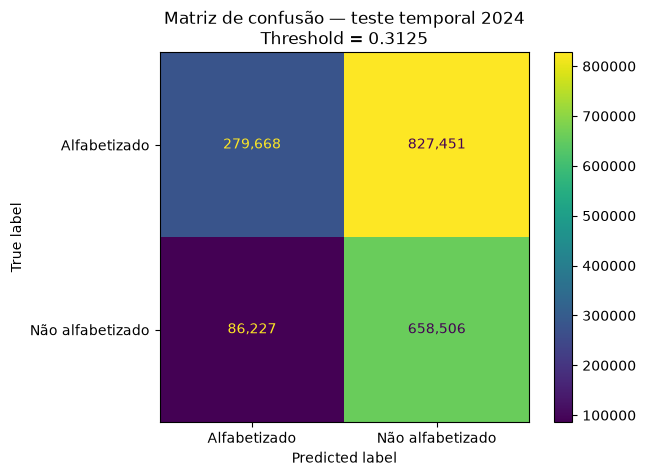

array([[279668, 827451],
       [ 86227, 658506]])

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_test = confusion_matrix(
    y_test,
    predicoes_test_otimo
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Alfabetizado", "Não alfabetizado"]
)

display_cm.plot(values_format=",d")
plt.title(
    f"Matriz de confusão — teste temporal 2024\n"
    f"Threshold = {threshold_otimo:.4f}"
)
plt.show()

cm_test

### 10.4 Comparação entre desenvolvimento e teste temporal

Para avaliar a estabilidade temporal do modelo, são comparadas as métricas obtidas nas previsões out-of-fold de 2023 com os resultados observados no teste temporal de 2024.

Em ambos os conjuntos é utilizado o mesmo limiar de decisão, definido exclusivamente a partir dos dados de desenvolvimento.

In [35]:
predicoes_oof_otimo = (
    probabilidades_oof >= threshold_otimo
).astype(int)

resultado_oof_otimo = calcular_metricas(
    y_dev,
    probabilidades_oof,
    predicoes_oof_otimo,
)

comparacao_temporal = pd.DataFrame({
    "desenvolvimento_oof_2023": resultado_oof_otimo,
    "teste_temporal_2024": resultado_test_otimo,
})

comparacao_temporal["variacao"] = (
    comparacao_temporal["teste_temporal_2024"]
    - comparacao_temporal["desenvolvimento_oof_2023"]
)

comparacao_temporal

,desenvolvimento_oof_2023,teste_temporal_2024,variacao
roc_auc,0.685063,0.636472,-0.048592
average_precision,0.592388,0.526164,-0.066223
balanced_accuracy,0.603191,0.568413,-0.034778
precision,0.481903,0.443153,-0.038750
recall,0.883027,0.884218,0.001191
f1,0.623524,0.590406,-0.033118


**Resultado:** O teste temporal de 2024 apresentou redução de desempenho em relação às previsões out-of-fold de 2023, com queda de aproximadamente 0,049 em ROC-AUC, 0,066 em Average Precision e 0,033 em F1.

Apesar da degradação temporal, o recall permaneceu estável, passando de 88,30% no desenvolvimento para 88,42% no teste temporal. Assim, com o limiar definido exclusivamente em 2023, o modelo manteve sua capacidade de identificar a maior parte dos alunos não alfabetizados no período posterior.

Os resultados de 2024 foram utilizados exclusivamente para avaliação temporal e não para reajuste do modelo, de seus hiperparâmetros ou do limiar de decisão.

## 11. Interpretabilidade do modelo

Após a avaliação do desempenho e da generalização temporal, é analisada a contribuição das variáveis utilizadas pelo modelo final.

A interpretabilidade é realizada exclusivamente após a definição do modelo, dos hiperparâmetros e do limiar de decisão, evitando utilizar o conjunto de teste temporal para decisões de seleção ou otimização.

Inicialmente, utiliza-se Permutation Importance no conjunto de desenvolvimento para avaliar quanto a perda de informação de cada característica afeta o desempenho preditivo do modelo.

In [36]:
from sklearn.inspection import permutation_importance

N_AMOSTRA_IMPORTANCIA = 100_000

X_importancia = X_dev.sample(
    n=min(N_AMOSTRA_IMPORTANCIA, len(X_dev)),
    random_state=RANDOM_STATE,
)

y_importancia = y_dev.loc[X_importancia.index]

resultado_importancia = permutation_importance(
    modelo_final,
    X_importancia,
    y_importancia,
    scoring="average_precision",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importancia_features = (
    pd.DataFrame({
        "variavel": X_importancia.columns,
        "importancia_media": resultado_importancia.importances_mean,
        "desvio_padrao": resultado_importancia.importances_std,
    })
    .sort_values("importancia_media", ascending=False)
    .reset_index(drop=True)
)

importancia_features.head(20)

,variavel,importancia_media,desvio_padrao
0,meta_alfabetizacao_2025,0.173164,0.000754
1,pct_in_biblioteca,0.001295,0.000095
2,total_qt_comp_portatil_aluno,0.000710,0.000164
3,pct_in_parque_infantil,0.000672,0.000210
4,pct_in_agua_rede_publica,0.000643,0.000053
5,alunos_por_sala,0.000637,0.000041
6,pct_in_biblioteca_sala_leitura,0.000588,0.000065
7,dispositivos_aluno_por_100_matriculas,0.000514,0.000022
8,alunos_por_docente,0.000430,0.000056
9,pct_in_patio_coberto,0.000430,0.000052


### 11.2 Principais variáveis segundo Permutation Importance

A importância das características é apresentada de forma relativa ao impacto causado no desempenho do modelo quando seus valores são permutados.

Valores maiores indicam maior contribuição da variável para a capacidade preditiva do modelo. Essa análise não representa relação causal.

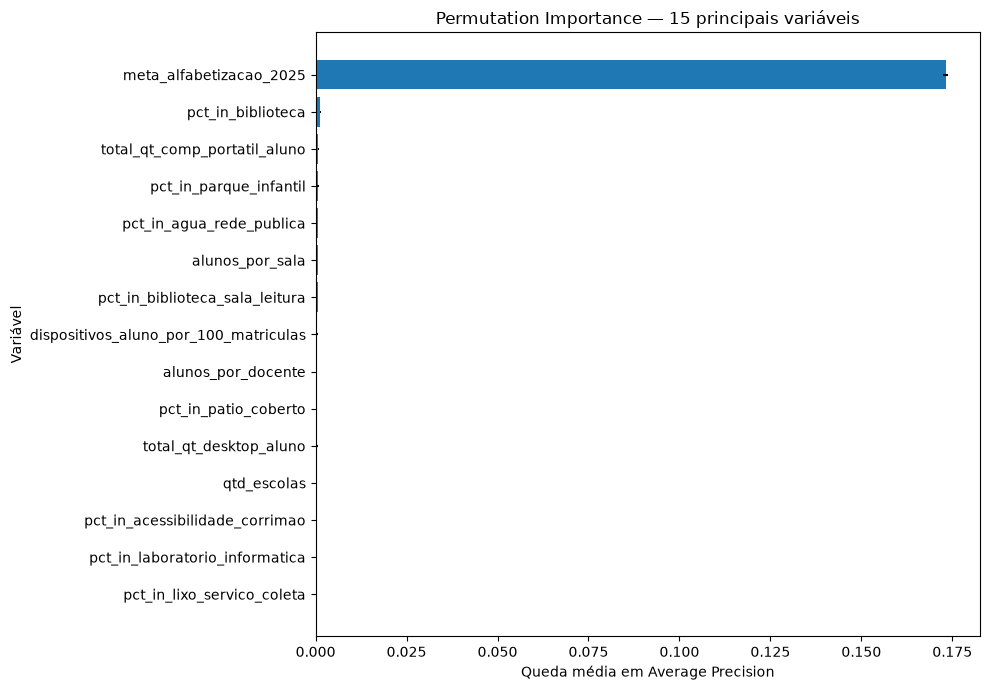

In [37]:
import matplotlib.pyplot as plt

top_importancias = (
    importancia_features
    .head(15)
    .sort_values("importancia_media")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importancias["variavel"],
    top_importancias["importancia_media"],
    xerr=top_importancias["desvio_padrao"],
)

plt.xlabel("Queda média em Average Precision")
plt.ylabel("Variável")
plt.title("Permutation Importance — 15 principais variáveis")

plt.tight_layout()
plt.show()

### 11.3 Teste de ablação da meta de alfabetização

A análise de Permutation Importance indicou forte predominância de `meta_alfabetizacao_2025` sobre as demais características.

Como essa variável representa uma meta territorial de política educacional, e não uma característica diretamente observada do aluno ou da infraestrutura escolar, é realizado um teste de ablação para verificar quanto da capacidade preditiva do modelo depende dessa informação.

A comparação é realizada exclusivamente no conjunto de desenvolvimento de 2023, preservando o teste temporal de 2024.

In [38]:
features_sem_meta = [
    coluna
    for coluna in features_modelagem
    if coluna != "meta_alfabetizacao_2025"
]

X_dev_sem_meta = X_dev[features_sem_meta].copy()

features_categoricas_sem_meta = [
    coluna
    for coluna in features_sem_meta
    if not pd.api.types.is_numeric_dtype(X_dev_sem_meta[coluna])
]

features_numericas_sem_meta = [
    coluna
    for coluna in features_sem_meta
    if pd.api.types.is_numeric_dtype(X_dev_sem_meta[coluna])
]

print(f"Features modelo atual: {len(features_modelagem)}")
print(f"Features sem meta: {len(features_sem_meta)}")
print(f"Removida: {set(features_modelagem) - set(features_sem_meta)}")

Features modelo atual: 37
Features sem meta: 36
Removida: {'meta_alfabetizacao_2025'}


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

pipeline_numerico_sem_meta = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

pipeline_categorico_sem_meta = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
            ),
        ),
    ]
)

preprocessor_sem_meta = ColumnTransformer(
    transformers=[
        (
            "numeric",
            pipeline_numerico_sem_meta,
            features_numericas_sem_meta,
        ),
        (
            "categorical",
            pipeline_categorico_sem_meta,
            features_categoricas_sem_meta,
        ),
    ],
    remainder="drop",
)

modelo_sem_meta = Pipeline(
    steps=[
        ("preprocessor", preprocessor_sem_meta),
        (
            "model",
            HistGradientBoostingClassifier(
                max_leaf_nodes=31,
                max_iter=100,
                learning_rate=0.05,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

print(modelo_sem_meta)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['qtd_escolas',
                                                   'pct_tp_localizacao_1',
                                                   'pct_localizacao_diferenciada',
                                                   'pct_in_agua_potavel',
                                                   'pct_in_agua_rede_publica',
                                                   'pct_in_energia_rede_publica',
                                                   'pct_in_esgoto_rede_publica',
                                                   'pct_in_lixo_servico_coleta',
                                                   'pct_i...
                                          

In [40]:
resultado_sem_meta = cross_validate(
    modelo_sem_meta,
    X_dev_sem_meta,
    y_dev,
    groups=groups_dev,
    cv=cv,
    scoring=metricas,
    n_jobs=-1,
)

resumo_sem_meta = pd.DataFrame({
    metrica: [
        resultado_sem_meta[f"test_{metrica}"].mean(),
        resultado_sem_meta[f"test_{metrica}"].std(),
    ]
    for metrica in metricas
}, index=["media", "desvio_padrao"])

resumo_sem_meta.T

,media,desvio_padrao
roc_auc,0.650404,0.002740
average_precision,0.553037,0.002599
balanced_accuracy,0.582906,0.003253
precision,0.596720,0.005120
recall,0.320209,0.016576
f1,0.416447,0.013203


In [41]:
comparacao_ablacao = pd.DataFrame({
    "com_meta": resumo_hist_otimizado.loc["media"],
    "sem_meta": resumo_sem_meta.loc["media"],
})

comparacao_ablacao["variacao"] = (
    comparacao_ablacao["sem_meta"]
    - comparacao_ablacao["com_meta"]
)

comparacao_ablacao

,com_meta,sem_meta,variacao
roc_auc,0.685198,0.650404,-0.034793
average_precision,0.592231,0.553037,-0.039194
balanced_accuracy,0.613648,0.582906,-0.030742
precision,0.604995,0.596720,-0.008274
recall,0.425190,0.320209,-0.104980
f1,0.499346,0.416447,-0.082899


### 11.4 Reotimização após o teste de ablação

O teste de ablação demonstrou que a meta municipal de alfabetização possui contribuição preditiva relevante. Entretanto, por representar uma meta de política educacional e não uma característica substantiva do contexto escolar, optou-se por removê-la do modelo de risco.

A variável permanece disponível para análises estratégicas posteriores relacionadas ao cumprimento das metas municipais.

Após essa decisão, o HistGradientBoosting é novamente otimizado utilizando exclusivamente as características selecionadas do Censo Escolar e os dados de desenvolvimento de 2023.

In [42]:
from sklearn.model_selection import RandomizedSearchCV

distribuicoes_parametros_sem_meta = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_iter": [100, 200],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0.0, 1.0, 5.0],
}

busca_sem_meta = RandomizedSearchCV(
    estimator=modelo_sem_meta,
    param_distributions=distribuicoes_parametros_sem_meta,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

busca_sem_meta.fit(
    X_dev_sem_meta,
    y_dev,
    groups=groups_dev,
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/erick/Projetos/tech_challenge_3_alfabetizacao/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__l2_regularization': [0.0, 1.0, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_iter': [100, 200], 'model__max_leaf_nodes': [15, 31, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score incho

In [43]:
print("Melhor Average Precision:")
print(f"{busca_sem_meta.best_score_:.6f}")

print("\nMelhores hiperparâmetros:")
busca_sem_meta.best_params_

Melhor Average Precision:
0.565905

Melhores hiperparâmetros:


{'model__max_leaf_nodes': 63,
 'model__max_iter': 200,
 'model__learning_rate': 0.1,
 'model__l2_regularization': 0.0}

In [44]:
modelo_sem_meta_otimizado = busca_sem_meta.best_estimator_

resultado_sem_meta_otimizado = cross_validate(
    modelo_sem_meta_otimizado,
    X_dev_sem_meta,
    y_dev,
    groups=groups_dev,
    cv=cv,
    scoring=metricas,
    n_jobs=-1,
)

resumo_sem_meta_otimizado = pd.DataFrame({
    metrica: [
        resultado_sem_meta_otimizado[f"test_{metrica}"].mean(),
        resultado_sem_meta_otimizado[f"test_{metrica}"].std(),
    ]
    for metrica in metricas
}, index=["media", "desvio_padrao"])

resumo_sem_meta_otimizado.T

,media,desvio_padrao
roc_auc,0.663734,0.003023
average_precision,0.565905,0.002001
balanced_accuracy,0.598937,0.001238
precision,0.588880,0.003901
recall,0.393950,0.005298
f1,0.472045,0.003152


In [45]:
comparacao_modelo_final = pd.DataFrame({
    "com_meta_otimizado": resumo_hist_otimizado.loc["media"],
    "sem_meta_antes_otimizacao": resumo_sem_meta.loc["media"],
    "sem_meta_otimizado": resumo_sem_meta_otimizado.loc["media"],
})

comparacao_modelo_final

,com_meta_otimizado,sem_meta_antes_otimizacao,sem_meta_otimizado
roc_auc,0.685198,0.650404,0.663734
average_precision,0.592231,0.553037,0.565905
balanced_accuracy,0.613648,0.582906,0.598937
precision,0.604995,0.596720,0.588880
recall,0.425190,0.320209,0.393950
f1,0.499346,0.416447,0.472045


### 11.5 Threshold do modelo definitivo sem meta

In [46]:
from sklearn.model_selection import cross_val_predict

probabilidades_oof_sem_meta = cross_val_predict(
    modelo_sem_meta_otimizado,
    X_dev_sem_meta,
    y_dev,
    groups=groups_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=2,
)[:, 1]

print(f"Probabilidades geradas: {len(probabilidades_oof_sem_meta):,}")
print(f"Mínima: {probabilidades_oof_sem_meta.min():.4f}")
print(f"Máxima: {probabilidades_oof_sem_meta.max():.4f}")

Probabilidades geradas: 1,502,809
Mínima: 0.0136
Máxima: 0.8809


In [47]:
from sklearn.metrics import precision_recall_curve

precision_curve_sem_meta, recall_curve_sem_meta, thresholds_sem_meta = (
    precision_recall_curve(
        y_dev,
        probabilidades_oof_sem_meta,
    )
)

f1_curve_sem_meta = (
    2 * precision_curve_sem_meta[:-1] * recall_curve_sem_meta[:-1]
    / (
        precision_curve_sem_meta[:-1]
        + recall_curve_sem_meta[:-1]
        + 1e-12
    )
)

indice_melhor_sem_meta = np.argmax(f1_curve_sem_meta)

threshold_otimo_sem_meta = thresholds_sem_meta[indice_melhor_sem_meta]

print(f"Threshold selecionado: {threshold_otimo_sem_meta:.4f}")
print(f"Precision: {precision_curve_sem_meta[indice_melhor_sem_meta]:.4f}")
print(f"Recall: {recall_curve_sem_meta[indice_melhor_sem_meta]:.4f}")
print(f"F1: {f1_curve_sem_meta[indice_melhor_sem_meta]:.4f}")

Threshold selecionado: 0.2977
Precision: 0.4688
Recall: 0.8901
F1: 0.6141


### 11.6 Avaliação temporal do modelo definitivo

In [48]:
X_test_sem_meta = X_test[features_sem_meta].copy()

modelo_final_sem_meta = modelo_sem_meta_otimizado

modelo_final_sem_meta.fit(
    X_dev_sem_meta,
    y_dev,
)

probabilidades_test_sem_meta = (
    modelo_final_sem_meta
    .predict_proba(X_test_sem_meta)[:, 1]
)

predicoes_test_sem_meta = (
    probabilidades_test_sem_meta >= threshold_otimo_sem_meta
).astype(int)

print(f"Observações no teste: {len(y_test):,}")
print(f"Threshold: {threshold_otimo_sem_meta:.4f}")

/home/erick/Projetos/tech_challenge_3_alfabetizacao/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Observações no teste: 1,851,852
Threshold: 0.2977


In [49]:
resultado_test_sem_meta = calcular_metricas(
    y_test,
    probabilidades_test_sem_meta,
    predicoes_test_sem_meta,
)

pd.Series(
    resultado_test_sem_meta,
    name="teste_temporal_2024"
).to_frame()

,teste_temporal_2024
roc_auc,0.603087
average_precision,0.500205
balanced_accuracy,0.545320
precision,0.428591
recall,0.878554
f1,0.576126


### 11.6.1 Conclusão do teste de ablação

A análise inicial de interpretabilidade mostrou que `meta_alfabetizacao_2025` concentrava grande parte da importância preditiva do modelo. Como essa variável representa uma meta municipal de política educacional, e não uma característica substantiva do contexto escolar, foi realizado um teste de ablação para avaliar o impacto de sua remoção.

A retirada da variável reduziu o desempenho do modelo. Após nova otimização utilizando exclusivamente os dados de desenvolvimento de 2023, o modelo sem a meta apresentou Average Precision de 0,5659 na validação cruzada, contra 0,5922 do modelo anteriormente otimizado com a meta.

O modelo sem a meta foi então reotimizado e teve seu limiar de decisão recalculado exclusivamente com predições out-of-fold de 2023. O threshold selecionado foi 0,2977, resultando em recall de 89,01% no desenvolvimento.

Na avaliação temporal de 2024, mantida fora das etapas de seleção e otimização, o modelo apresentou:

- ROC-AUC: 0,6031
- Average Precision: 0,5002
- Balanced Accuracy: 0,5453
- Precision: 0,4286
- Recall: 0,8786
- F1-score: 0,5761

Apesar da redução na capacidade discriminativa, optou-se pelo modelo sem `meta_alfabetizacao_2025`. A decisão evita que uma meta territorial domine a previsão e permite que a interpretação do modelo seja baseada nas características do contexto escolar provenientes do Censo Escolar.

O recall permaneceu relativamente estável entre o desenvolvimento e o teste temporal (89,01% e 87,86%, respectivamente), indicando que o modelo preservou sua capacidade de identificar a maior parte dos alunos não alfabetizados em 2024.

As metas de alfabetização não são descartadas do projeto. Elas permanecem disponíveis para a etapa posterior de análise do cumprimento das metas municipais.

> **Sustenta H3**: a análise de ablação mostra que a meta municipal contém informação preditiva, mas sua natureza de indicador agregado de política pública, e não de característica individual do aluno, sustenta a decisão conservadora de excluí-la do modelo final.

### 11.7 Interpretabilidade do modelo final

Após a remoção da meta municipal e a reotimização do modelo, a importância das características é recalculada utilizando o modelo definitivo.

A análise utiliza Permutation Importance sobre uma amostra do conjunto de desenvolvimento de 2023, adotando Average Precision como métrica, em consistência com o critério utilizado na otimização do modelo.

A importância representa a redução do desempenho preditivo causada pela permutação dos valores de cada característica. Portanto, valores maiores indicam maior contribuição da variável para a capacidade preditiva do modelo.

Os resultados representam associações preditivas e não devem ser interpretados como relações causais.

### 11.7.1 Permutation Importance

In [50]:
from sklearn.inspection import permutation_importance

N_AMOSTRA_IMPORTANCIA = 100_000

X_importancia_sem_meta = X_dev_sem_meta.sample(
    n=min(N_AMOSTRA_IMPORTANCIA, len(X_dev_sem_meta)),
    random_state=RANDOM_STATE,
)

y_importancia_sem_meta = y_dev.loc[X_importancia_sem_meta.index]

resultado_importancia_sem_meta = permutation_importance(
    modelo_final_sem_meta,
    X_importancia_sem_meta,
    y_importancia_sem_meta,
    scoring="average_precision",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importancia_features_sem_meta = (
    pd.DataFrame({
        "variavel": X_importancia_sem_meta.columns,
        "importancia_media": resultado_importancia_sem_meta.importances_mean,
        "desvio_padrao": resultado_importancia_sem_meta.importances_std,
    })
    .sort_values(
        "importancia_media",
        ascending=False,
    )
    .reset_index(drop=True)
)

importancia_features_sem_meta.head(20)

,variavel,importancia_media,desvio_padrao
0,alunos_por_sala,0.011482,0.000234
1,pct_in_agua_rede_publica,0.011309,0.000027
2,pct_in_parque_infantil,0.009951,0.000827
3,pct_tp_localizacao_1,0.009680,0.000472
4,pct_in_biblioteca_sala_leitura,0.008884,0.000723
5,pct_in_internet_aprendizagem,0.008320,0.000853
6,pct_in_internet,0.008167,0.000416
7,alunos_por_docente,0.008065,0.000243
8,pct_in_acessibilidade_corrimao,0.008031,0.000556
9,media_qt_salas_utilizadas,0.007345,0.000219


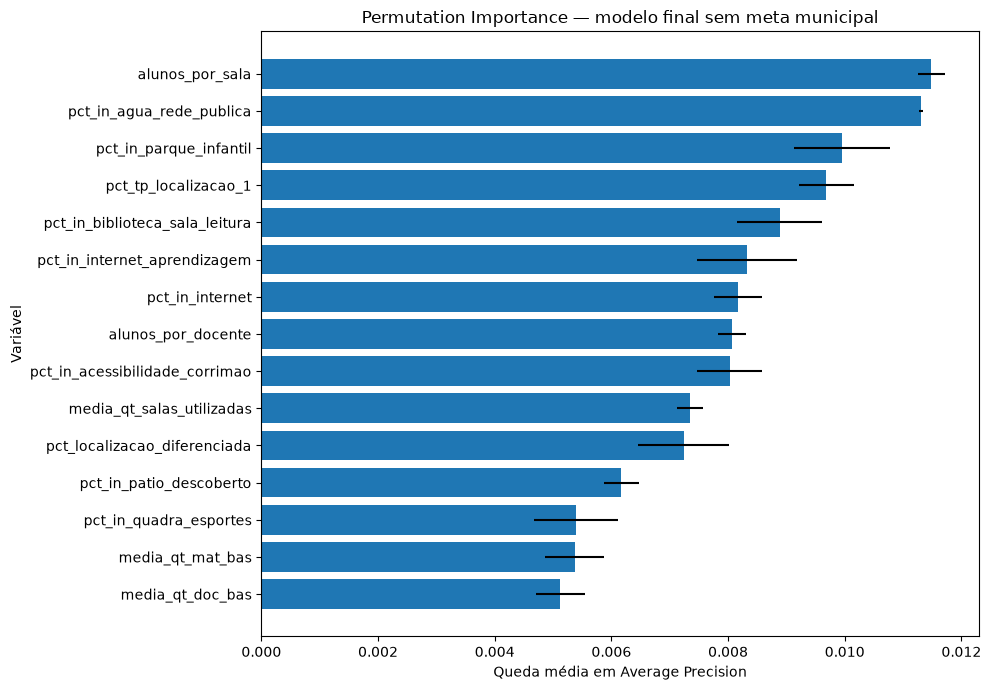

In [51]:
top_importancias_sem_meta = (
    importancia_features_sem_meta
    .head(15)
    .sort_values("importancia_media")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importancias_sem_meta["variavel"],
    top_importancias_sem_meta["importancia_media"],
    xerr=top_importancias_sem_meta["desvio_padrao"],
)

plt.xlabel("Queda média em Average Precision")
plt.ylabel("Variável")
plt.title(
    "Permutation Importance — modelo final sem meta municipal"
)

plt.tight_layout()
plt.show()

#### 11.7.2 Persistência da Permutation Importance

Os resultados da Permutation Importance do modelo final são persistidos para utilização nas análises estratégicas posteriores.

O artefato preserva, para cada característica, a queda média de Average Precision causada por sua permutação e o respectivo desvio-padrão entre as repetições.

In [52]:
from pathlib import Path

OUTPUT_PERMUTATION = Path(
    "../data/processed/importancia_permutation_modelo_final.parquet"
)

importancia_permutation = (
    importancia_features_sem_meta
    .copy()
    .reset_index(drop=True)
)

importancia_permutation["posicao"] = (
    importancia_permutation.index + 1
)

importancia_permutation.to_parquet(
    OUTPUT_PERMUTATION,
    index=False,
)

print(f"Arquivo salvo em: {OUTPUT_PERMUTATION}")
print(
    "Características persistidas: "
    f"{len(importancia_permutation):,}"
)

display(importancia_permutation.head(15))

Arquivo salvo em: ../data/processed/importancia_permutation_modelo_final.parquet
Características persistidas: 36


,variavel,importancia_media,desvio_padrao,posicao
0,alunos_por_sala,0.011482,0.000234,1
1,pct_in_agua_rede_publica,0.011309,0.000027,2
2,pct_in_parque_infantil,0.009951,0.000827,3
3,pct_tp_localizacao_1,0.009680,0.000472,4
4,pct_in_biblioteca_sala_leitura,0.008884,0.000723,5
5,pct_in_internet_aprendizagem,0.008320,0.000853,6
6,pct_in_internet,0.008167,0.000416,7
7,alunos_por_docente,0.008065,0.000243,8
8,pct_in_acessibilidade_corrimao,0.008031,0.000556,9
9,media_qt_salas_utilizadas,0.007345,0.000219,10


#### Interpretação

Após a retirada da meta municipal, a importância preditiva mostrou-se distribuída entre diferentes características do contexto escolar.

As maiores contribuições estão associadas a características como número de alunos por sala, infraestrutura de abastecimento de água, disponibilidade de parque infantil, localização, biblioteca ou sala de leitura, conectividade e relação entre alunos e docentes.

Diferentemente do modelo anterior, não foi observada concentração extrema da importância em uma única característica. O modelo final utiliza informações provenientes de diferentes dimensões do contexto escolar para realizar suas previsões.

Essas importâncias representam contribuição para o desempenho preditivo do modelo e não estabelecem relações de causa e efeito entre as características escolares e a alfabetização.

### 11.8 Direção das principais associações

A Permutation Importance identifica quais características apresentam maior contribuição preditiva, mas não informa como diferentes valores dessas características se relacionam com as previsões do modelo.

Para complementar a interpretação, são analisadas as principais variáveis por meio de Partial Dependence, permitindo observar a relação média entre cada característica e a probabilidade prevista de não alfabetização.

Essas relações são descritivas do comportamento do modelo e não representam efeitos causais.

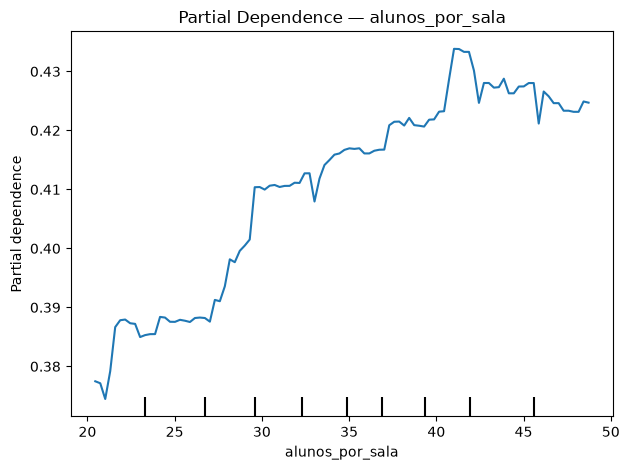

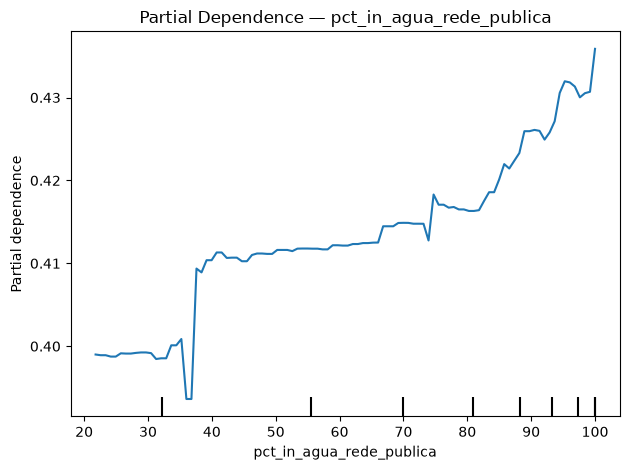

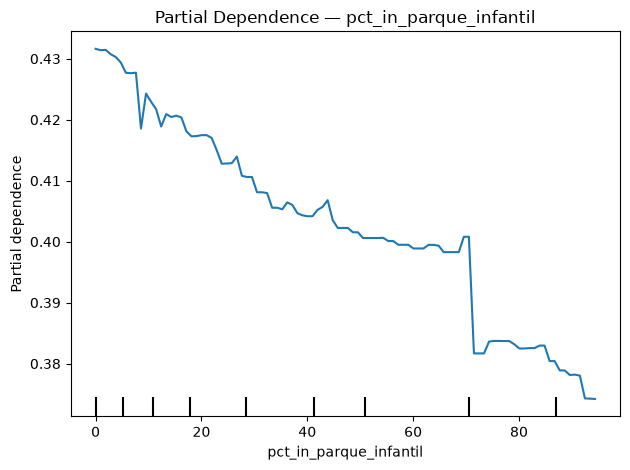

,variavel,valor_feature,partial_dependence
0,alunos_por_sala,20.451613,0.377473
1,alunos_por_sala,20.737206,0.377140
2,alunos_por_sala,21.022798,0.374472
3,alunos_por_sala,21.308391,0.379198
4,alunos_por_sala,21.593983,0.386658


In [53]:
from sklearn.inspection import PartialDependenceDisplay

variaveis_pdp = [
    "alunos_por_sala",
    "pct_in_agua_rede_publica",
    "pct_in_parque_infantil",
]

resultados_pdp = []

for variavel in variaveis_pdp:
    display_pdp = PartialDependenceDisplay.from_estimator(
        modelo_final_sem_meta,
        X_importancia_sem_meta,
        features=[variavel],
        kind="average",
    )

    resultado_variavel = display_pdp.pd_results[0]

    valores_feature = resultado_variavel["grid_values"][0]
    valores_dependencia = resultado_variavel["average"][0]

    resultados_pdp.append(
        pd.DataFrame({
            "variavel": variavel,
            "valor_feature": valores_feature,
            "partial_dependence": valores_dependencia,
        })
    )

    plt.title(f"Partial Dependence — {variavel}")
    plt.tight_layout()
    plt.show()

pdp_modelo_final = pd.concat(
    resultados_pdp,
    ignore_index=True,
)

pdp_modelo_final.head()

#### Interpretação das relações

Os gráficos de Partial Dependence mostram que as principais características apresentam relações não lineares com a probabilidade prevista de não alfabetização.

- **Alunos por sala:** o modelo apresenta uma associação predominantemente crescente. Turmas com maior número médio de alunos estão associadas a maior probabilidade prevista de não alfabetização.

- **Abastecimento por rede pública de água:** também é observada uma associação predominantemente crescente no modelo. Esse resultado deve ser interpretado com cautela, pois pode refletir características contextuais correlacionadas e não implica que o abastecimento por rede pública aumente o risco de não alfabetização.

- **Parque infantil:** apresenta associação predominantemente inversa. Maior presença dessa infraestrutura está associada a menor probabilidade prevista de não alfabetização.

Essas relações descrevem o comportamento preditivo do modelo e não permitem estabelecer relações causais entre as características escolares e a alfabetização.

#### 11.8.1 Persistência dos resultados de Partial Dependence

Os pontos das curvas de Partial Dependence das características selecionadas são persistidos para utilização nas análises estratégicas posteriores.

O artefato preserva, para cada característica analisada, os valores avaliados e a resposta média estimada pelo modelo, permitindo reutilizar a forma das relações identificadas sem recalcular o modelo.

In [54]:
from pathlib import Path

OUTPUT_PDP = Path(
    "../data/processed/partial_dependence_modelo_final.parquet"
)

pdp_modelo_final.to_parquet(
    OUTPUT_PDP,
    index=False,
)

print(f"Arquivo salvo em: {OUTPUT_PDP}")
print(f"Pontos persistidos: {len(pdp_modelo_final):,}")
print(
    "Características persistidas:",
    pdp_modelo_final["variavel"].nunique(),
)

display(
    pdp_modelo_final
    .groupby("variavel")
    .agg(
        pontos=("valor_feature", "size"),
        valor_min=("valor_feature", "min"),
        valor_max=("valor_feature", "max"),
        pd_min=("partial_dependence", "min"),
        pd_max=("partial_dependence", "max"),
    )
)

Arquivo salvo em: ../data/processed/partial_dependence_modelo_final.parquet
Pontos persistidos: 300
Características persistidas: 3


,pontos,valor_min,valor_max,pd_min,pd_max
variavel,,,,,
alunos_por_sala,100,20.451613,48.725275,0.374472,0.433828
pct_in_agua_rede_publica,100,21.794872,100.000000,0.393635,0.435876
pct_in_parque_infantil,100,0.000000,94.366197,0.374205,0.431623


### 11.9 Interpretabilidade com SHAP

Como complemento à Permutation Importance e aos gráficos de Partial Dependence, é utilizada a técnica SHAP para analisar a contribuição das características nas previsões do modelo final.

A análise é aplicada ao modelo final sem a variável de meta municipal, preservando a configuração adotada após o teste de ablação.

Como o modelo utiliza um pipeline de preprocessamento, uma amostra dos dados é primeiro transformada pelo `ColumnTransformer` e posteriormente explicada pelo estimador `HistGradientBoostingClassifier`.

Os valores SHAP representam a contribuição de cada característica para a saída do modelo. Valores positivos e negativos indicam contribuições em direções opostas na predição, mas não devem ser interpretados como efeitos causais.

In [55]:
import shap

N_AMOSTRA_SHAP = 5_000

X_shap = X_dev_sem_meta.sample(
    n=min(N_AMOSTRA_SHAP, len(X_dev_sem_meta)),
    random_state=RANDOM_STATE,
)

preprocessor_shap = (
    modelo_final_sem_meta
    .named_steps["preprocessor"]
)

modelo_shap = (
    modelo_final_sem_meta
    .named_steps["model"]
)

X_shap_transformado = preprocessor_shap.transform(X_shap)

nomes_features_shap = (
    preprocessor_shap
    .get_feature_names_out()
)

print(f"Observações: {X_shap_transformado.shape[0]:,}")
print(f"Features após preprocessamento: {X_shap_transformado.shape[1]:,}")

Observações: 5,000
Features após preprocessamento: 36


#### 11.9.1 Cálculo dos valores SHAP

O explicador SHAP é aplicado ao estimador final utilizando a matriz já transformada pelo pipeline de preprocessamento.

A análise utiliza uma amostra de 5.000 observações para tornar o cálculo computacionalmente viável, mantendo uma quantidade suficiente de registros para a análise global das contribuições das características.

In [56]:
explainer_shap = shap.TreeExplainer(
    modelo_shap
)

valores_shap = explainer_shap(
    X_shap_transformado
)

valores_shap.feature_names = list(nomes_features_shap)

print(
    f"Dimensões dos valores SHAP: "
    f"{valores_shap.values.shape}"
)

valores_shap.feature_names = [
    nome
    .replace("numeric__", "")
    .replace("categorical__", "")
    for nome in nomes_features_shap
]

print(
    f"Valor base médio: "
    f"{np.mean(valores_shap.base_values):.4f}"
)

Dimensões dos valores SHAP: (5000, 36)
Valor base médio: -0.3897


#### 11.9.2 Visão global das contribuições SHAP

O gráfico SHAP abaixo apresenta simultaneamente a magnitude e a direção das contribuições das características para as previsões do modelo.

Cada ponto representa uma observação. A posição no eixo horizontal corresponde ao valor SHAP da característica, enquanto a escala de cores representa o valor assumido pela própria característica.

Características com maior dispersão horizontal apresentam maior influência sobre as previsões. A direção dos valores SHAP permite ainda identificar se determinados valores da característica tendem a aumentar ou reduzir a saída produzida pelo modelo.

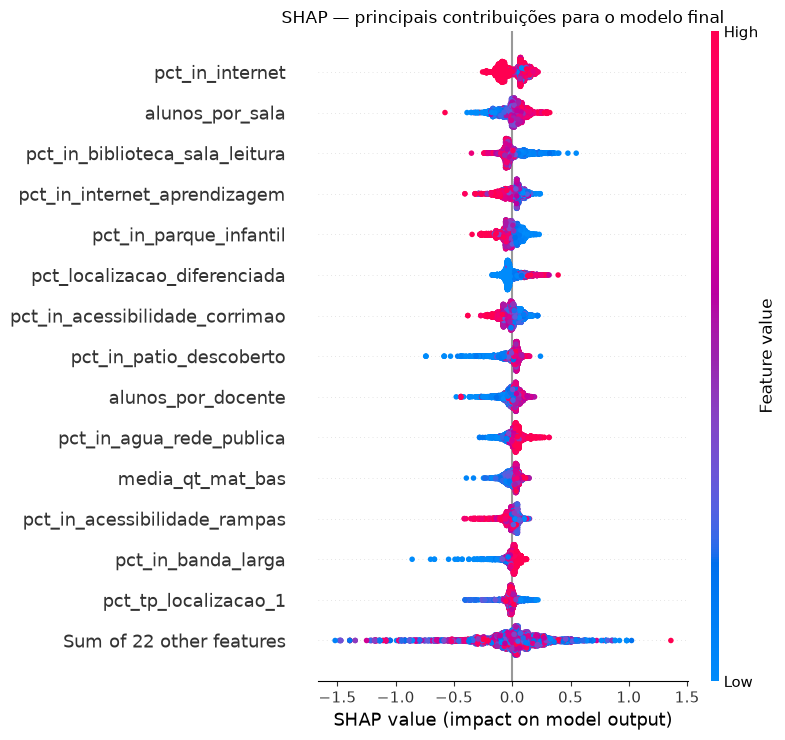

In [57]:
shap.plots.beeswarm(
    valores_shap,
    max_display=15,
    show=False,
)

plt.title(
    "SHAP — principais contribuições para o modelo final"
)

plt.tight_layout()
plt.show()

In [58]:
print("Classes do modelo:", modelo_shap.classes_)

Classes do modelo: [0 1]


#### 11.9.3 Importância global segundo SHAP

Para complementar a análise de direção das contribuições, os valores SHAP absolutos são agregados para produzir uma medida de importância global das características.

Quanto maior o valor SHAP absoluto médio, maior foi, em média, a contribuição da característica para as previsões realizadas na amostra analisada.

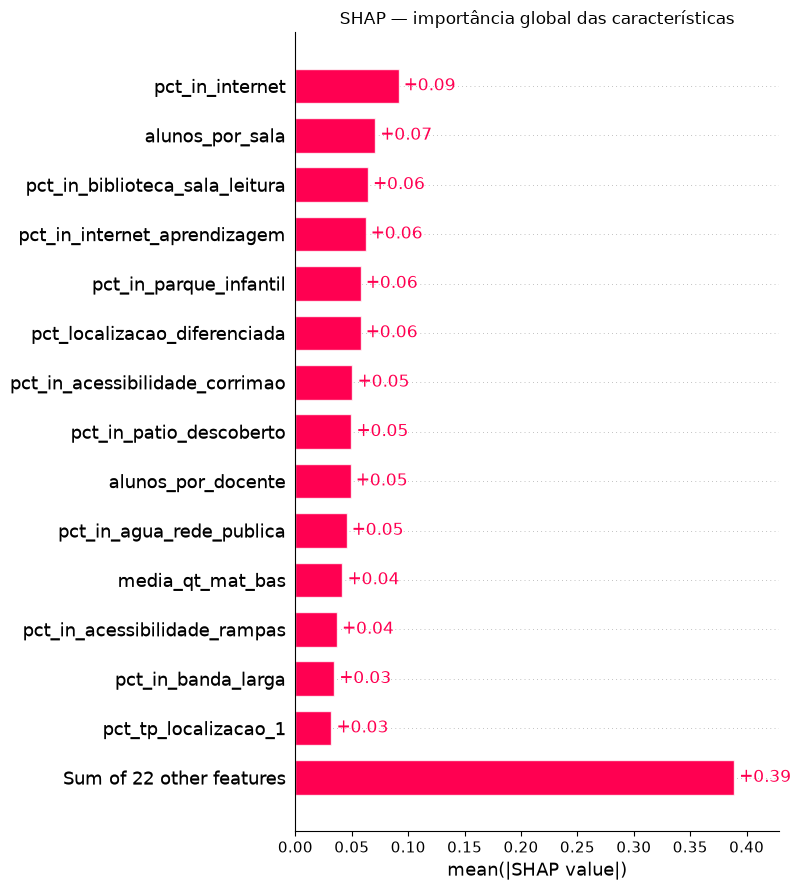

In [59]:
shap.plots.bar(
    valores_shap,
    max_display=15,
    show=False,
)

plt.title(
    "SHAP — importância global das características"
)

plt.tight_layout()
plt.show()

#### 11.9.4 Interpretação dos resultados

A análise SHAP reforça que as previsões do modelo final são construídas a partir de um conjunto distribuído de características do contexto escolar, sem concentração da explicação em uma única variável.

Entre as características individuais de maior contribuição global destacam-se o percentual de escolas com internet, o número de alunos por sala, a disponibilidade de biblioteca ou sala de leitura, o uso de internet para aprendizagem, a presença de parque infantil e características relacionadas à localização e à infraestrutura escolar.

O gráfico beeswarm complementa o ranking global ao mostrar que a influência das características não depende apenas de sua importância média, mas também dos valores assumidos em cada observação. Como a classe positiva do modelo corresponde à não alfabetização, contribuições SHAP positivas deslocam a saída do modelo em direção a essa classe, enquanto contribuições negativas atuam na direção oposta.

Os resultados do SHAP devem ser analisados em conjunto com a Permutation Importance e os gráficos de Partial Dependence. As técnicas possuem objetivos distintos e, portanto, não precisam produzir rankings idênticos: a Permutation Importance avalia a perda de desempenho causada pela perturbação de uma característica, o Partial Dependence avalia o comportamento médio da predição ao variar determinadas características e o SHAP decompõe as previsões em contribuições atribuídas às características.

Em conjunto, as análises indicam que o modelo utiliza múltiplas dimensões do contexto escolar, especialmente características relacionadas à infraestrutura, conectividade, organização escolar e disponibilidade de recursos.

Essas associações descrevem o comportamento preditivo do modelo e não devem ser interpretadas como relações causais entre as características escolares e a alfabetização.

> **Sustenta H1**: as variáveis de infraestrutura escolar dominam o ranking de importância global (Permutation Importance e SHAP), reforçando seu papel como principais fatores contextuais associados ao risco.

#### 11.9.5 Persistência da importância global SHAP

A importância global calculada pelo SHAP é consolidada em formato tabular e persistida para utilização na etapa de aplicação estratégica.

Para cada característica, utiliza-se a média dos valores SHAP absolutos na amostra analisada. O artefato permite reutilizar os resultados de interpretabilidade sem recalcular o SHAP nos notebooks posteriores.

In [60]:
importancia_shap = pd.DataFrame({
    "variavel": valores_shap.feature_names,
    "importancia_shap": np.abs(
        valores_shap.values
    ).mean(axis=0),
})

importancia_shap = (
    importancia_shap
    .sort_values(
        "importancia_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

importancia_shap["posicao"] = (
    importancia_shap.index + 1
)

display(
    importancia_shap[
        [
            "posicao",
            "variavel",
            "importancia_shap",
        ]
    ].head(15)
)

,posicao,variavel,importancia_shap
0,1,pct_in_internet,0.091452
1,2,alunos_por_sala,0.070669
2,3,pct_in_biblioteca_sala_leitura,0.064228
3,4,pct_in_internet_aprendizagem,0.062189
4,5,pct_in_parque_infantil,0.057879
5,6,pct_localizacao_diferenciada,0.057782
6,7,pct_in_acessibilidade_corrimao,0.050570
7,8,pct_in_patio_descoberto,0.049572
8,9,alunos_por_docente,0.048963
9,10,pct_in_agua_rede_publica,0.045327


In [61]:
resumo_shap = pd.DataFrame({
    "variavel": valores_shap.feature_names,
    "importancia_shap": np.abs(
        valores_shap.values
    ).mean(axis=0),
    "shap_medio": valores_shap.values.mean(axis=0),
})

resumo_shap = (
    resumo_shap
    .sort_values(
        "importancia_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

resumo_shap["posicao"] = resumo_shap.index + 1

display(
    resumo_shap[
        [
            "posicao",
            "variavel",
            "importancia_shap",
            "shap_medio",
        ]
    ].head(15)
)

,posicao,variavel,importancia_shap,shap_medio
0,1,pct_in_internet,0.091452,0.003020
1,2,alunos_por_sala,0.070669,0.003025
2,3,pct_in_biblioteca_sala_leitura,0.064228,0.004635
3,4,pct_in_internet_aprendizagem,0.062189,0.003156
4,5,pct_in_parque_infantil,0.057879,-0.001293
5,6,pct_localizacao_diferenciada,0.057782,0.002263
6,7,pct_in_acessibilidade_corrimao,0.050570,-0.005752
7,8,pct_in_patio_descoberto,0.049572,-0.004751
8,9,alunos_por_docente,0.048963,0.002009
9,10,pct_in_agua_rede_publica,0.045327,0.016815


In [62]:
direcao_shap = []

for i, variavel in enumerate(valores_shap.feature_names):
    valores_feature = X_shap_transformado[:, i]
    valores_contribuicao = valores_shap.values[:, i]

    correlacao = pd.Series(
        valores_feature
    ).corr(
        pd.Series(valores_contribuicao),
        method="spearman",
    )

    direcao_shap.append({
        "variavel": variavel,
        "correlacao_feature_shap": correlacao,
    })

direcao_shap = pd.DataFrame(direcao_shap)

resumo_shap = resumo_shap.merge(
    direcao_shap,
    on="variavel",
    how="left",
)

display(
    resumo_shap[
        [
            "posicao",
            "variavel",
            "importancia_shap",
            "shap_medio",
            "correlacao_feature_shap",
        ]
    ].head(15)
)

,posicao,variavel,importancia_shap,shap_medio,correlacao_feature_shap
0,1,pct_in_internet,0.091452,0.003020,-0.767468
1,2,alunos_por_sala,0.070669,0.003025,0.811859
2,3,pct_in_biblioteca_sala_leitura,0.064228,0.004635,-0.804314
3,4,pct_in_internet_aprendizagem,0.062189,0.003156,-0.795564
4,5,pct_in_parque_infantil,0.057879,-0.001293,-0.881886
5,6,pct_localizacao_diferenciada,0.057782,0.002263,0.813918
6,7,pct_in_acessibilidade_corrimao,0.050570,-0.005752,-0.793891
7,8,pct_in_patio_descoberto,0.049572,-0.004751,0.661928
8,9,alunos_por_docente,0.048963,0.002009,0.663593
9,10,pct_in_agua_rede_publica,0.045327,0.016815,0.792782


In [63]:
from pathlib import Path

OUTPUT_SHAP = Path(
    "../data/processed/importancia_shap_modelo_final.parquet"
)

resumo_shap.to_parquet(
    OUTPUT_SHAP,
    index=False,
)

print(f"Arquivo salvo em: {OUTPUT_SHAP}")
print(f"Características persistidas: {len(resumo_shap):,}")

display(resumo_shap.head(15))

Arquivo salvo em: ../data/processed/importancia_shap_modelo_final.parquet
Características persistidas: 36


,variavel,importancia_shap,shap_medio,posicao,correlacao_feature_shap
0,pct_in_internet,0.091452,0.003020,1,-0.767468
1,alunos_por_sala,0.070669,0.003025,2,0.811859
2,pct_in_biblioteca_sala_leitura,0.064228,0.004635,3,-0.804314
3,pct_in_internet_aprendizagem,0.062189,0.003156,4,-0.795564
4,pct_in_parque_infantil,0.057879,-0.001293,5,-0.881886
5,pct_localizacao_diferenciada,0.057782,0.002263,6,0.813918
6,pct_in_acessibilidade_corrimao,0.050570,-0.005752,7,-0.793891
7,pct_in_patio_descoberto,0.049572,-0.004751,8,0.661928
8,alunos_por_docente,0.048963,0.002009,9,0.663593
9,pct_in_agua_rede_publica,0.045327,0.016815,10,0.792782


### 11.10 Persistência das predições para aplicação estratégica

As predições produzidas pelo modelo final no conjunto temporal de 2024 são persistidas para utilização nas análises estratégicas posteriores.

O artefato contém os identificadores necessários para agregação territorial, o resultado observado, a probabilidade estimada de não alfabetização e a classificação obtida com o threshold definido exclusivamente no conjunto de desenvolvimento de 2023.

In [64]:
from pathlib import Path

OUTPUT_PREDICOES = Path(
    "../data/processed/predicoes_modelo_final_2024.parquet"
)

predicoes_estrategicas_2024 = df.loc[
    mask_test,
    [
        "ano",
        "id_municipio",
        "id_municipio_nome",
        "id_escola",
        "id_aluno",
        "alfabetizado",
    ],
].copy()

predicoes_estrategicas_2024["prob_nao_alfabetizado"] = (
    probabilidades_test_sem_meta
)

predicoes_estrategicas_2024["pred_nao_alfabetizado"] = (
    predicoes_test_sem_meta
)

predicoes_estrategicas_2024.to_parquet(
    OUTPUT_PREDICOES,
    index=False,
)

print(f"Arquivo salvo em: {OUTPUT_PREDICOES}")
print(f"Linhas: {len(predicoes_estrategicas_2024):,}")

predicoes_estrategicas_2024.head()

Arquivo salvo em: ../data/processed/predicoes_modelo_final_2024.parquet
Linhas: 1,851,852


,ano,id_municipio,id_municipio_nome,id_escola,id_aluno,alfabetizado,prob_nao_alfabetizado,pred_nao_alfabetizado
1502809,2024,1100023,Ariquemes,60000062,11000001,Não,0.345256,1
1502810,2024,1100023,Ariquemes,60000062,11000002,Sim,0.345256,1
1502811,2024,1100023,Ariquemes,60000062,11000003,Não,0.345256,1
1502812,2024,1100023,Ariquemes,60000062,11000004,Não,0.345256,1
1502813,2024,1100023,Ariquemes,60000062,11000005,Sim,0.345256,1


#### 11.10.1 Validação do artefato persistido

Após a persistência, o artefato é novamente carregado para verificar sua integridade e garantir que a base utilizada na aplicação estratégica corresponde às predições produzidas pelo modelo final.

São verificadas a quantidade de registros, a presença de valores ausentes e os limites das probabilidades estimadas.

In [65]:
predicoes_validacao = pd.read_parquet(
    OUTPUT_PREDICOES
)

print(f"Linhas persistidas: {len(predicoes_validacao):,}")
print(f"Colunas: {predicoes_validacao.shape[1]}")

print("\nValores ausentes:")
display(
    predicoes_validacao
    .isna()
    .sum()
    .to_frame("nulos")
)

print("\nIntervalo das probabilidades:")
print(
    predicoes_validacao["prob_nao_alfabetizado"]
    .agg(["min", "max"])
)

Linhas persistidas: 1,851,852
Colunas: 8

Valores ausentes:


,nulos
ano,0
id_municipio,0
id_municipio_nome,0
id_escola,0
id_aluno,0
alfabetizado,0
prob_nao_alfabetizado,0
pred_nao_alfabetizado,0



Intervalo das probabilidades:
min    0.029151
max    0.793054
Name: prob_nao_alfabetizado, dtype: float64
